# 06. 장애인콜택시 의료 목적지 × 의료기관 분포 분석 — 탐색적 데이터 분석(EDA)

이 노트북은 STEP3(EDA)을 다룬다. STEP1(목적정의)·STEP2(데이터준비)는 `05_medical_destination_purpose_and_data.ipynb`,
작업계획은 `notebooks_docs_lye/plan_medical_destination_analysis.md` 참고.

## 이 노트북의 목적

05에서 만든 구·동 단위 결합 데이터(콜택시 목적지 건수 + 의료기관 종별 개수)를 바탕으로,
① 콜택시 전체 이용 패턴 ② 목적지 지역 분포 ③ 의료기관 분포 ④ 의료기관 구성비 ⑤ 이상치(심층분석 후보)를
그래프와 함께 확인한다. 여기서는 패턴을 "확인"만 하고, 상관관계·유형화 같은 본 분석은 07에서 다룬다.

## 사용 데이터
- `data/processed/region_dong_call_hospital_combined.csv` — 구·동 단위 결합 데이터 (주 분석단위, 431행)
- `data/processed/region_gu_call_hospital_combined.csv` — 구 단위 결합 데이터 (보조, 25행)
- `data/processed/서울시설공단_장애인콜택시 탑승내역_정제_20251231.csv` — 시간대별 추이 확인용 원본 (읽기 전용, **수정 금지**)

## ⚠️ 해석 원칙 (프로젝트 공통)
- "장애인콜택시 이용자가 A병원을 많이 방문한다" 등 인과관계·개별 병원 방문 확정 표현 금지
- 모든 결과는 [확인된 사실]/[탐색적 관계]/[가설]/[인과관계] 4단계로 구분
- `data/raw/hospital_info_seoul.csv`는 서울시 전체 의료기관이 아니라 P1(핵심)+P2(보조) 우선순위군만 수집한 것 (근거: 05 노트북 2-5절)

In [1]:
import platform
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_rows", 60)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

dong_path = PROCESSED_DIR / "region_dong_call_hospital_combined.csv"
gu_path = PROCESSED_DIR / "region_gu_call_hospital_combined.csv"
boarding_path = PROCESSED_DIR / "서울시설공단_장애인콜택시 탑승내역_정제_20251231.csv"

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
for p in (dong_path, gu_path, boarding_path):
    print(f"{p.name} exists: {p.exists()}")

PROJECT_ROOT: c:\Users\young\my_project\260901_call_taxi_DA
region_dong_call_hospital_combined.csv exists: True
region_gu_call_hospital_combined.csv exists: True
서울시설공단_장애인콜택시 탑승내역_정제_20251231.csv exists: True


## 0. 데이터 로드

구·동/구 단위 결합 데이터를 로드하고, 시간대별 추이 확인을 위해 콜택시 원본도 함께 로드한다.
원본은 05와 동일하게 **탑승완료(승차·하차 O, 취소 X) + 서울 25개구 목적지** 기준으로 다시 필터링한다.

In [2]:
dong_df = pd.read_csv(dong_path, encoding="utf-8-sig")
gu_df = pd.read_csv(gu_path, encoding="utf-8-sig")

print(f"dong_df: {dong_df.shape}")
print(f"gu_df: {gu_df.shape}")
display(dong_df.head())

dong_df: (431, 15)
gu_df: (25, 14)


,목적구,행정동,콜택시_목적지_건수,병원,보건소,보건지소,상급종합병원,요양병원,의원,정신병원,종합병원,한의원,P1_의료기관_합계,P2_의료기관_합계,의료기관_총수
0,강남구,개포1동,358,0,0,0,0,0,1,0,0,0,1,0,1
1,강남구,개포2동,1874,0,0,0,0,0,30,0,0,15,30,15,45
2,강남구,개포3동,3558,0,0,0,0,0,12,0,0,5,12,5,17
3,강남구,개포4동,380,0,0,0,0,0,19,0,0,8,19,8,27
4,강남구,논현1동,924,6,0,0,0,0,264,0,0,27,270,27,297


In [3]:
SEOUL_25 = [
    "강남구", "강동구", "강북구", "강서구", "관악구",
    "광진구", "구로구", "금천구", "노원구", "도봉구",
    "동대문구", "동작구", "마포구", "서대문구", "서초구",
    "성동구", "성북구", "송파구", "양천구", "영등포구",
    "용산구", "은평구", "종로구", "중구", "중랑구",
]

df_boarding = pd.read_csv(boarding_path, encoding="utf-8-sig", low_memory=False)

completed = df_boarding[
    df_boarding["승차일시"].notna()
    & df_boarding["하차일시"].notna()
    & df_boarding["취소일시"].isna()
].copy()
completed_seoul_dest = completed[completed["목적구"].isin(SEOUL_25)].copy()

for col in ["접수일시", "승차일시"]:
    completed_seoul_dest[col] = pd.to_datetime(completed_seoul_dest[col], errors="coerce")

print(f"탑승완료(서울 25개구 목적지) 건수: {len(completed_seoul_dest):,}")

탑승완료(서울 25개구 목적지) 건수: 1,369,283


## 1. 콜택시 전체 이용 현황

전체 건수와 함께 일별·월별·요일별·시간대별 추이를 확인한다. 시간 기준은 실제 승차가 발생한 `승차일시`를 사용한다.

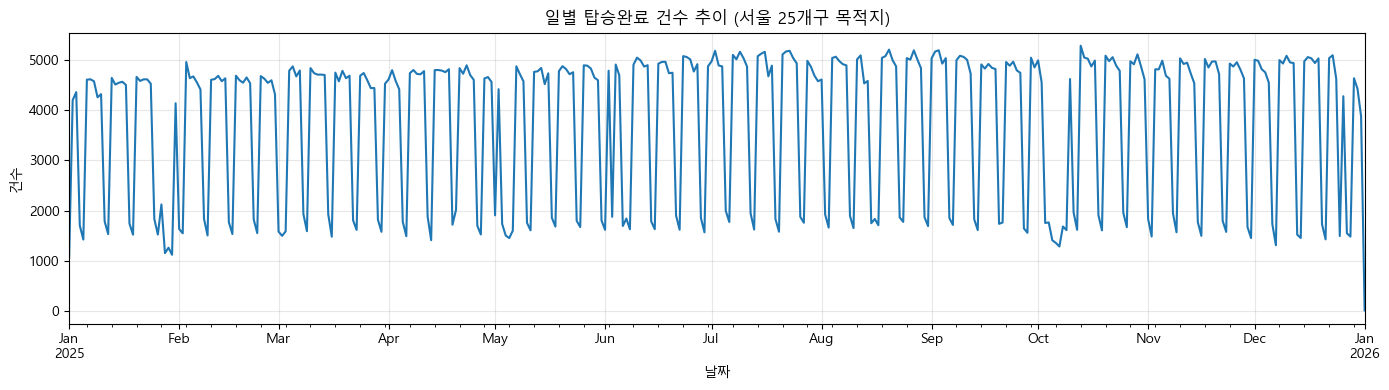

일평균 건수: 3741.2건, 최댓값: 5,274건(2025-10-13), 최솟값: 18건(2026-01-01)


In [4]:
daily = completed_seoul_dest.set_index("승차일시").resample("D").size()

plt.figure(figsize=(14, 4))
daily.plot()
plt.title("일별 탑승완료 건수 추이 (서울 25개구 목적지)")
plt.xlabel("날짜")
plt.ylabel("건수")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"일평균 건수: {daily.mean():.1f}건, 최댓값: {daily.max():,}건({daily.idxmax().date()}), 최솟값: {daily.min():,}건({daily.idxmin().date()})")

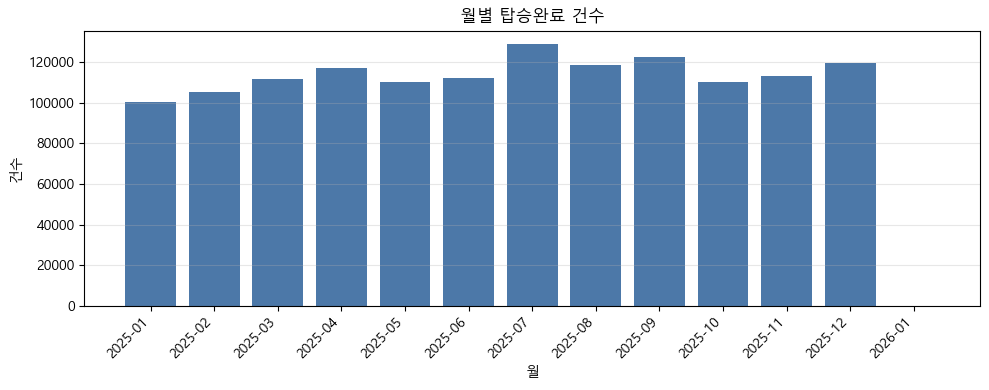

In [5]:
monthly = completed_seoul_dest.set_index("승차일시").resample("MS").size()

plt.figure(figsize=(10, 4))
plt.bar(monthly.index.strftime("%Y-%m"), monthly.values, color="#4c78a8")
plt.title("월별 탑승완료 건수")
plt.xlabel("월")
plt.ylabel("건수")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

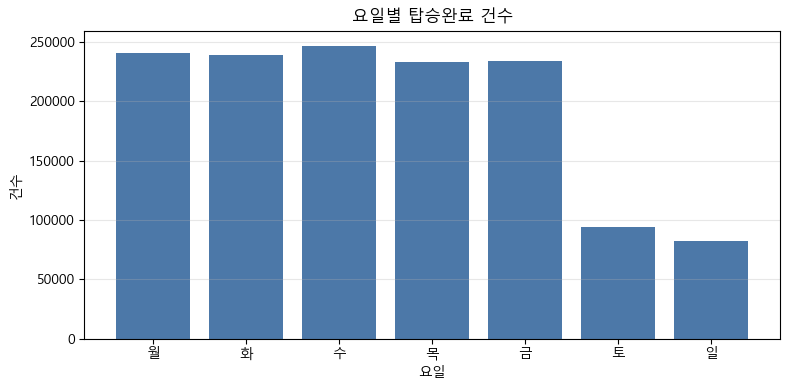

승차일시
월    240896
화    238832
수    246650
목    232971
금    233843
토     93809
일     82282
Name: count, dtype: int64

In [6]:
weekday_names = ["월", "화", "수", "목", "금", "토", "일"]
weekday_count = completed_seoul_dest["승차일시"].dt.weekday.value_counts().reindex(range(7)).rename(index=dict(enumerate(weekday_names)))

plt.figure(figsize=(8, 4))
plt.bar(weekday_count.index, weekday_count.values, color="#4c78a8")
plt.title("요일별 탑승완료 건수")
plt.xlabel("요일")
plt.ylabel("건수")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

display(weekday_count)

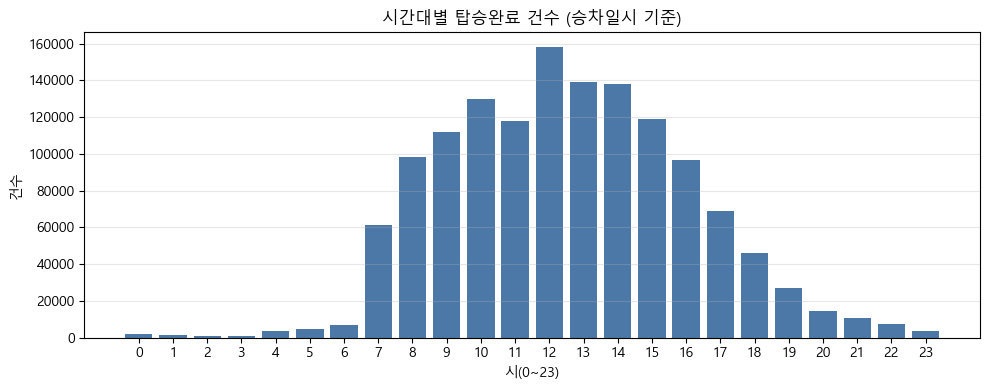

In [7]:
hourly_count = completed_seoul_dest["승차일시"].dt.hour.value_counts().sort_index()

plt.figure(figsize=(10, 4))
plt.bar(hourly_count.index, hourly_count.values, color="#4c78a8")
plt.title("시간대별 탑승완료 건수 (승차일시 기준)")
plt.xlabel("시(0~23)")
plt.ylabel("건수")
plt.xticks(range(0, 24))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 2. 목적지 지역 분석

구별·동별 목적지 건수 순위와 상위 지역 집중도를 확인한다.

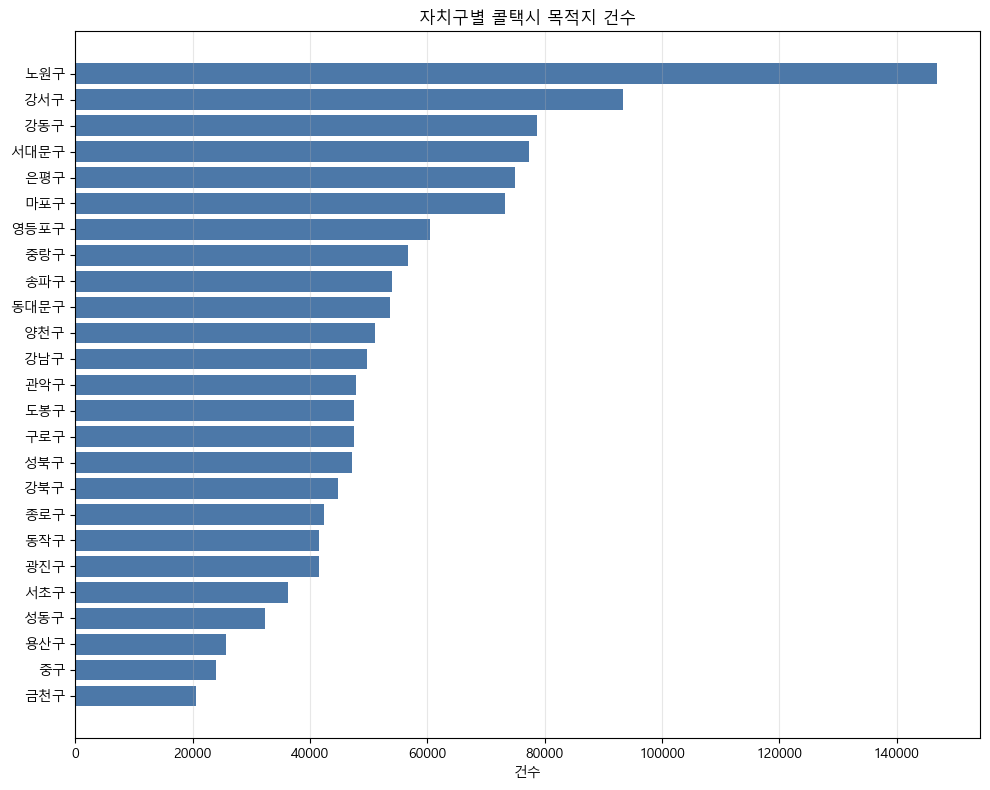

,목적구,콜택시_목적지_건수
0,노원구,146831
1,강서구,93425
2,강동구,78684
3,서대문구,77346
4,은평구,74925
5,마포구,73304
6,영등포구,60518
7,중랑구,56697
8,송파구,54062
9,동대문구,53680


In [8]:
gu_rank = gu_df.sort_values("콜택시_목적지_건수", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 8))
plot_data = gu_rank.sort_values("콜택시_목적지_건수")
plt.barh(plot_data["목적구"], plot_data["콜택시_목적지_건수"], color="#4c78a8")
plt.title("자치구별 콜택시 목적지 건수")
plt.xlabel("건수")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

display(gu_rank[["목적구", "콜택시_목적지_건수"]])

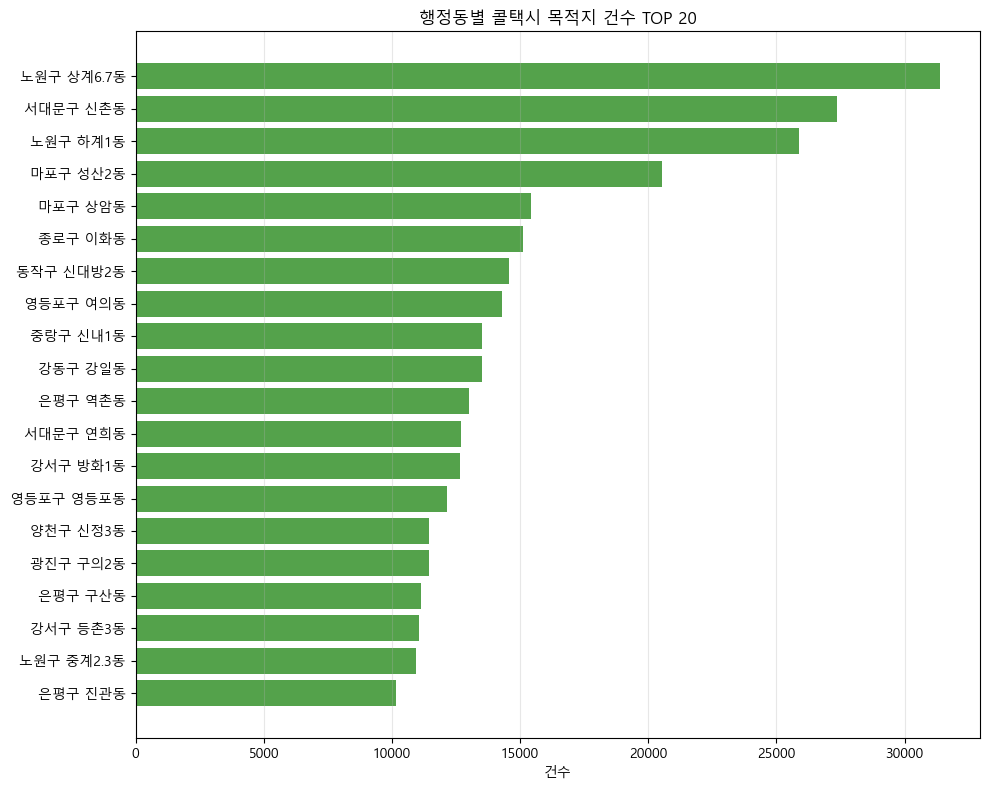

,목적구,행정동,콜택시_목적지_건수
141,노원구,상계6.7동,31372
218,서대문구,신촌동,27363
151,노원구,하계1동,25892
206,마포구,성산2동,20545
202,마포구,상암동,15420
384,종로구,이화동,15126
195,동작구,신대방2동,14564
341,영등포구,여의동,14308
427,중랑구,신내1동,13529
22,강동구,강일동,13505


In [9]:
top20_dong = dong_df.sort_values("콜택시_목적지_건수", ascending=False).head(20).copy()
top20_dong["구동"] = top20_dong["목적구"] + " " + top20_dong["행정동"]

plt.figure(figsize=(10, 8))
plot_data = top20_dong.sort_values("콜택시_목적지_건수")
plt.barh(plot_data["구동"], plot_data["콜택시_목적지_건수"], color="#54a24b")
plt.title("행정동별 콜택시 목적지 건수 TOP 20")
plt.xlabel("건수")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

display(top20_dong[["목적구", "행정동", "콜택시_목적지_건수"]])

상위 10개 행정동이 전체 목적지 건수의 14.0%를 차지
상위 20개 행정동이 전체 목적지 건수의 22.5%를 차지
상위 50개 행정동이 전체 목적지 건수의 39.4%를 차지


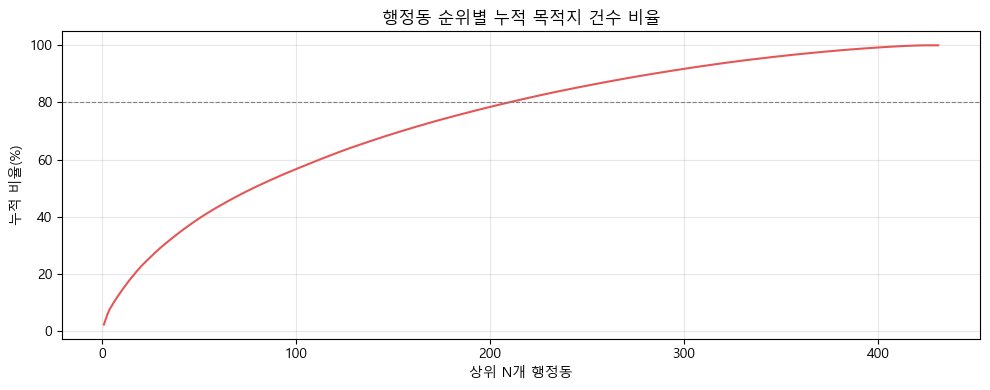

In [10]:
dong_sorted = dong_df.sort_values("콜택시_목적지_건수", ascending=False).reset_index(drop=True)
dong_sorted["누적비율(%)"] = (
    dong_sorted["콜택시_목적지_건수"].cumsum() / dong_sorted["콜택시_목적지_건수"].sum() * 100
)

for n in (10, 20, 50):
    ratio = dong_sorted.loc[n - 1, "누적비율(%)"]
    print(f"상위 {n}개 행정동이 전체 목적지 건수의 {ratio:.1f}%를 차지")

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(dong_sorted) + 1), dong_sorted["누적비율(%)"], color="#e45756")
plt.axhline(80, color="gray", linestyle="--", linewidth=0.8)
plt.title("행정동 순위별 누적 목적지 건수 비율")
plt.xlabel("상위 N개 행정동")
plt.ylabel("누적 비율(%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 의료기관 분포 분석

종별 총수와 구별 분포를 확인한다. (전체가 아니라 P1+P2 우선순위군만 수집된 데이터임에 유의 — 05 노트북 2-5절 참고)

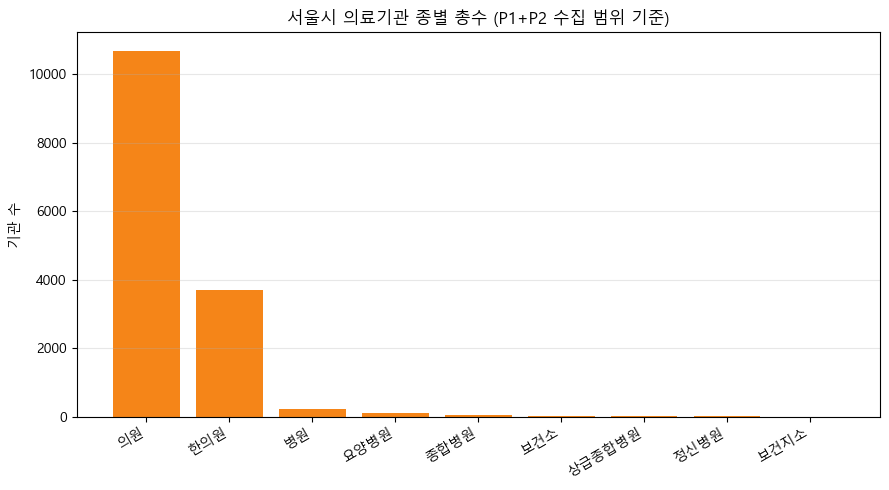

의원        10696
한의원        3719
병원          232
요양병원        101
종합병원         45
보건소          25
상급종합병원       14
정신병원         13
보건지소         11
dtype: int64

In [11]:
facility_cols = ["의원", "한의원", "병원", "종합병원", "요양병원", "상급종합병원", "보건소", "보건지소", "정신병원"]
facility_total = gu_df[facility_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(facility_total.index, facility_total.values, color="#f58518")
plt.title("서울시 의료기관 종별 총수 (P1+P2 수집 범위 기준)")
plt.ylabel("기관 수")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

display(facility_total)

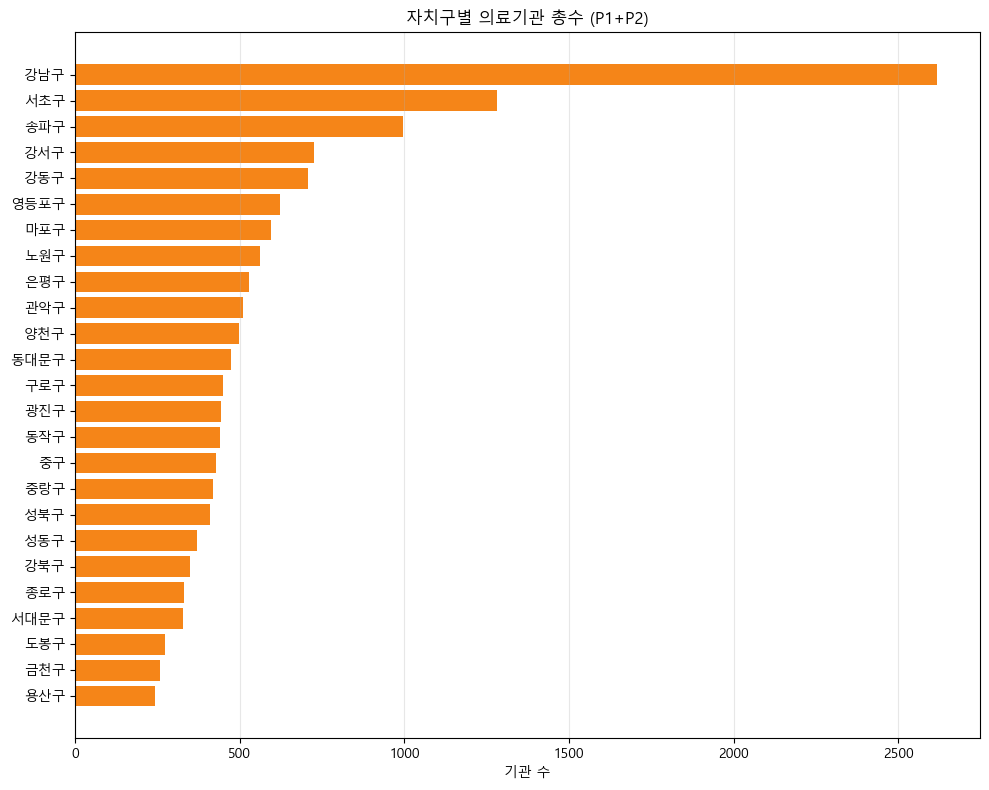

,목적구,P1_의료기관_합계,P2_의료기관_합계,의료기관_총수
0,강남구,2220,398,2618
1,서초구,1007,274,1281
2,송파구,721,276,997
3,강서구,517,207,724
4,강동구,509,198,707
5,영등포구,464,158,622
6,마포구,447,149,596
7,노원구,413,148,561
8,은평구,365,163,528
9,관악구,370,139,509


In [12]:
gu_facility_rank = gu_df.sort_values("의료기관_총수", ascending=False)

plt.figure(figsize=(10, 8))
plot_data = gu_facility_rank.sort_values("의료기관_총수")
plt.barh(plot_data["목적구"], plot_data["의료기관_총수"], color="#f58518")
plt.title("자치구별 의료기관 총수 (P1+P2)")
plt.xlabel("기관 수")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

display(gu_facility_rank[["목적구", "P1_의료기관_합계", "P2_의료기관_합계", "의료기관_총수"]].reset_index(drop=True))

## 4. 의료기관 구성비 분석

구별 의료기관 '수'가 아니라 '구성'(종별 비율)을 확인한다. **의료기관 총수가 적은 구는 비율 하나가 크게 흔들릴 수 있으므로 해석에 주의한다.**

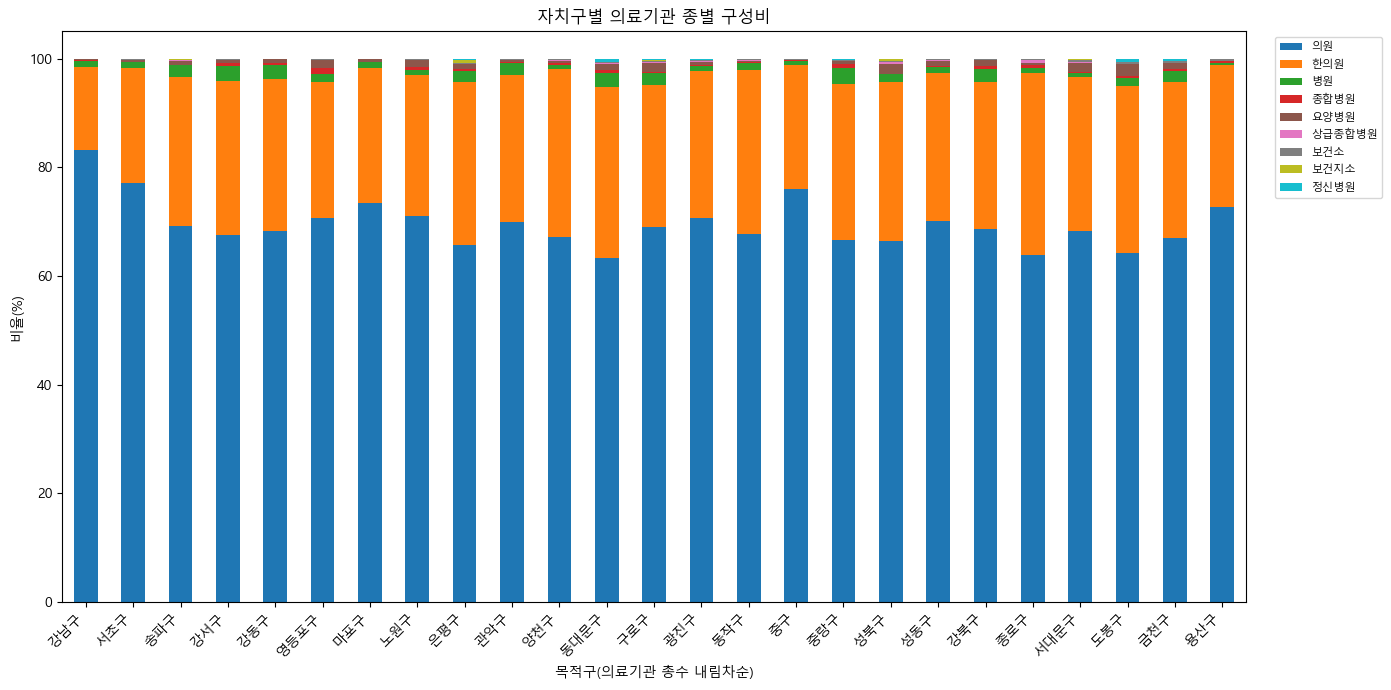

[주의] 의료기관 총수 300개 미만 구 (비율 해석 시 유의): ['금천구', '도봉구', '용산구']


In [13]:
composition = gu_df.set_index("목적구")[facility_cols]
composition_ratio = composition.div(composition.sum(axis=1), axis=0) * 100
composition_ratio = composition_ratio.loc[gu_df.sort_values("의료기관_총수", ascending=False)["목적구"]]

ax = composition_ratio.plot(
    kind="bar", stacked=True, figsize=(14, 7), colormap="tab10"
)
ax.set_title("자치구별 의료기관 종별 구성비")
ax.set_ylabel("비율(%)")
ax.set_xlabel("목적구(의료기관 총수 내림차순)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

low_count_gu = gu_df[gu_df["의료기관_총수"] < 300]["목적구"].tolist()
print(f"[주의] 의료기관 총수 300개 미만 구 (비율 해석 시 유의): {low_count_gu}")

## 5. 이상치 확인

구 단위로 "의료기관 많음/콜 적음", "의료기관 적음/콜 많음" 지역을 식별한다. 여기서는 나열만 하고, 실제 상관관계·유형화 검증은 07에서 진행한다.

In [14]:
gu_eda = gu_df.copy()
gu_eda["콜_순위"] = gu_eda["콜택시_목적지_건수"].rank(ascending=False)
gu_eda["의료_순위"] = gu_eda["의료기관_총수"].rank(ascending=False)
gu_eda["순위차이"] = gu_eda["의료_순위"] - gu_eda["콜_순위"]

print("[관찰] 의료기관 순위 대비 콜 순위가 훨씬 높은 지역 (의료기관 少 + 콜 多 후보)")
display(
    gu_eda.sort_values("순위차이").head(5)[
        ["목적구", "콜택시_목적지_건수", "콜_순위", "의료기관_총수", "의료_순위", "순위차이"]
    ]
)

print("\n[관찰] 콜 순위 대비 의료기관 순위가 훨씬 높은 지역 (의료기관 多 + 콜 少 후보)")
display(
    gu_eda.sort_values("순위차이", ascending=False).head(5)[
        ["목적구", "콜택시_목적지_건수", "콜_순위", "의료기관_총수", "의료_순위", "순위차이"]
    ]
)

[관찰] 의료기관 순위 대비 콜 순위가 훨씬 높은 지역 (의료기관 少 + 콜 多 후보)


,목적구,콜택시_목적지_건수,콜_순위,의료기관_총수,의료_순위,순위차이
14,서초구,36283,21.0,1281,2.0,-19.0
0,강남구,49717,12.0,2618,1.0,-11.0
23,중구,24064,24.0,429,16.0,-8.0
5,광진구,41518,20.0,444,14.0,-6.0
17,송파구,54062,9.0,997,3.0,-6.0



[관찰] 콜 순위 대비 의료기관 순위가 훨씬 높은 지역 (의료기관 多 + 콜 少 후보)


,목적구,콜택시_목적지_건수,콜_순위,의료기관_총수,의료_순위,순위차이
13,서대문구,77346,4.0,328,22.0,18.0
9,도봉구,47460,14.0,274,23.0,9.0
24,중랑구,56697,8.0,420,17.0,9.0
8,노원구,146831,1.0,561,8.0,7.0
21,은평구,74925,5.0,528,9.0,4.0


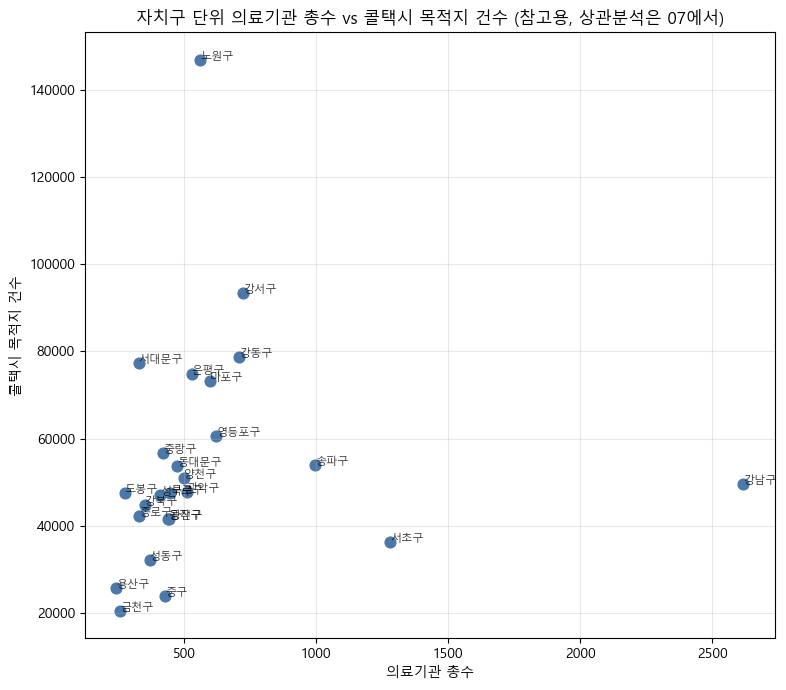

In [15]:
plt.figure(figsize=(8, 7))
plt.scatter(gu_eda["의료기관_총수"], gu_eda["콜택시_목적지_건수"], s=60, color="#4c78a8")
for _, row in gu_eda.iterrows():
    plt.annotate(row["목적구"], (row["의료기관_총수"], row["콜택시_목적지_건수"]), fontsize=8, alpha=0.8)
plt.title("자치구 단위 의료기관 총수 vs 콜택시 목적지 건수 (참고용, 상관분석은 07에서)")
plt.xlabel("의료기관 총수")
plt.ylabel("콜택시 목적지 건수")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## EDA 요약

**[관찰]**
- 콜택시 목적지 건수는 자치구별로 편차가 크고(최댓값–최솟값 격차), 소수 행정동에 집중되는 경향이 위 누적비율 그래프에서 확인된다.
- 의료기관 총수(P1+P2 기준)도 구별 편차가 크며, 강남구·서초구처럼 의원·한의원 비중이 매우 높은 구가 존재한다.
- 콜 순위와 의료기관 순위가 크게 엇갈리는 지역(순위차이 상위/하위 5개)이 존재한다.

**[해석]**
- 목적지 건수 상위 지역이 곧 의료기관 상위 지역은 아니며, 두 지표는 독립적으로 움직일 수 있다.

**[검증 필요]**
- 위 "순위차이" 기반 관찰은 상관계수·유의성 검정을 거치지 않은 단순 순위 비교다. 실제 통계적 관계는 07에서 확인한다.
- 의료기관 총수가 적은 구의 구성비(4절)는 표본이 작아 해석에 주의가 필요하다.

**[다음 분석]**
- 07에서 구·동 단위로 상관관계(Pearson/Spearman), 의료기관 종별별 개별 관계, 지역 유형화(A/B/C/D)를 진행한다.
- 이번 절에서 식별한 순위차이 상위/하위 지역을 07의 "주요 지역 심층 분석" 후보로 우선 검토한다.